In [1]:
import pandas as pd
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.stats import sigma_clip
from scipy.stats import binned_statistic
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import scipy.integrate

In [2]:
nbins = 10

In [3]:

# Helper funciton that plots the scatter and error bars. 
# ax - matplotlib axis where the plots will be drawn. 
# mask - the mask that selects which rows to use. 
# xcol - name of the df collumn to put on the x axis. Note residuals are always on the y-axis here.

def scatter_with_errors(ax, xcol, nbins=None):
    # Raw values
    x = df[xcol].values
    y = df["residual_centered"].values
    yerr = yerr_all.values

    # --- sigma clipping in y (vertical axis) ---
    # NOTE: sigma clipping has been moved OUTSIDE this function.
    # This function now assumes `mask` already includes whatever global sigma-clip
    # (or other cleaning) you want. In other words: this function only plots.
    #
    # UPDATE: we no longer pass a mask into this function because we now DROP
    # any unwanted rows upstream (sigma-clip + physical cuts). Therefore the
    # dataframe `df` is already the final cleaned sample when this function is called.

    # --- scatter cloud ---
    ax.scatter(x, y, **point_kwargs)

    # --- individual error bars ---
    # Important to note that the way that this function works we will be drawing
    # an error bar line from y - yerr to y + yerr. Where y_err = sigma_i
    ax.errorbar(
        x, y, yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=0.5,
        alpha=0.25,
        zorder=2,
    )

    # horizontal reference
    ax.axhline(0, linestyle="--", color="orange")

    # --- BINNING WITH ERROR PROPAGATION ---
    # NOTE: we set the number of bins here.

    # binned_statistic is a function tha takes (x, values, ststics, bins, range)
    # x - an array of positions along the x-axis.
    # values - the vaules on which the statistics are computed inside each bin.
    # NOTE: here we want to just count the number of points in each bin on the
    # horizontal axis of our plots. Therefore we parse "x" as both the argument and the
    # value and simply choose "count" as our statistics option.
    # bin_edges is an array of bin boundaries
    # binnumber - the index for which data point each bin belongs in.
    # This is done mostly becaue the data on the horizontal axis is not ranked so
    # we have to give it an identifier when we do our bin statistics later on.
    # Bin centers are just calcualted as the middle points between one bin edge and another.
    _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Creating arrays for ht residuals.
    binned_y = []
    binned_yerr = []

    # Just a fancy way of saying "for each bin"
    # We end up appending the data and error means into
    # an array.
    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i

        # If a bin is empty, skip it (avoid divide-by-zero)
        if np.sum(in_bin) == 0:
            binned_y.append(np.nan)
            binned_yerr.append(np.nan)
            continue

        # We end up finding data and errro associated
        # with the number of bin that we are in.
        y_bin = y[in_bin]
        err_bin = yerr[in_bin]

        # inverse-variance weights
        w = 1.0 / (err_bin**2)

        # weighted mean
        y_mean = np.sum(w * y_bin) / np.sum(w)

        # propagated error on the mean
        err_mean = 1.0 / np.sqrt(np.sum(w))

        binned_y.append(y_mean)
        binned_yerr.append(err_mean)

    # Convert to arrays and only plot finite bins
    binned_y = np.array(binned_y)
    binned_yerr = np.array(binned_yerr)
    ok = np.isfinite(binned_y) & np.isfinite(binned_yerr)

    ax.errorbar(
        bin_centers[ok],
        binned_y[ok],
        yerr=binned_yerr[ok],
        fmt="o",
        color="blue",
        markersize=5,
        capsize=3,
        zorder=5  # Keeps the data looking on top
    )

776 SNe before paper-based quality cuts.
579 SNe after paper-based quality cuts.


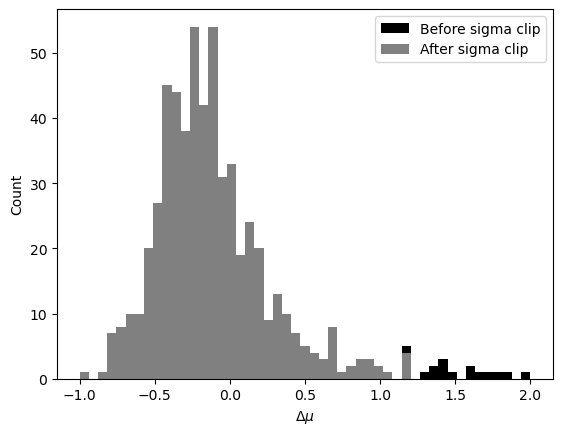

563 SNe after sigma clipping (Δμ)
555 SNe after SFR <= 2.5 cut.
553 SNe after DN4000 >= 0.5 cut.
550 SNe after AGE >= 2 Gyr cut.


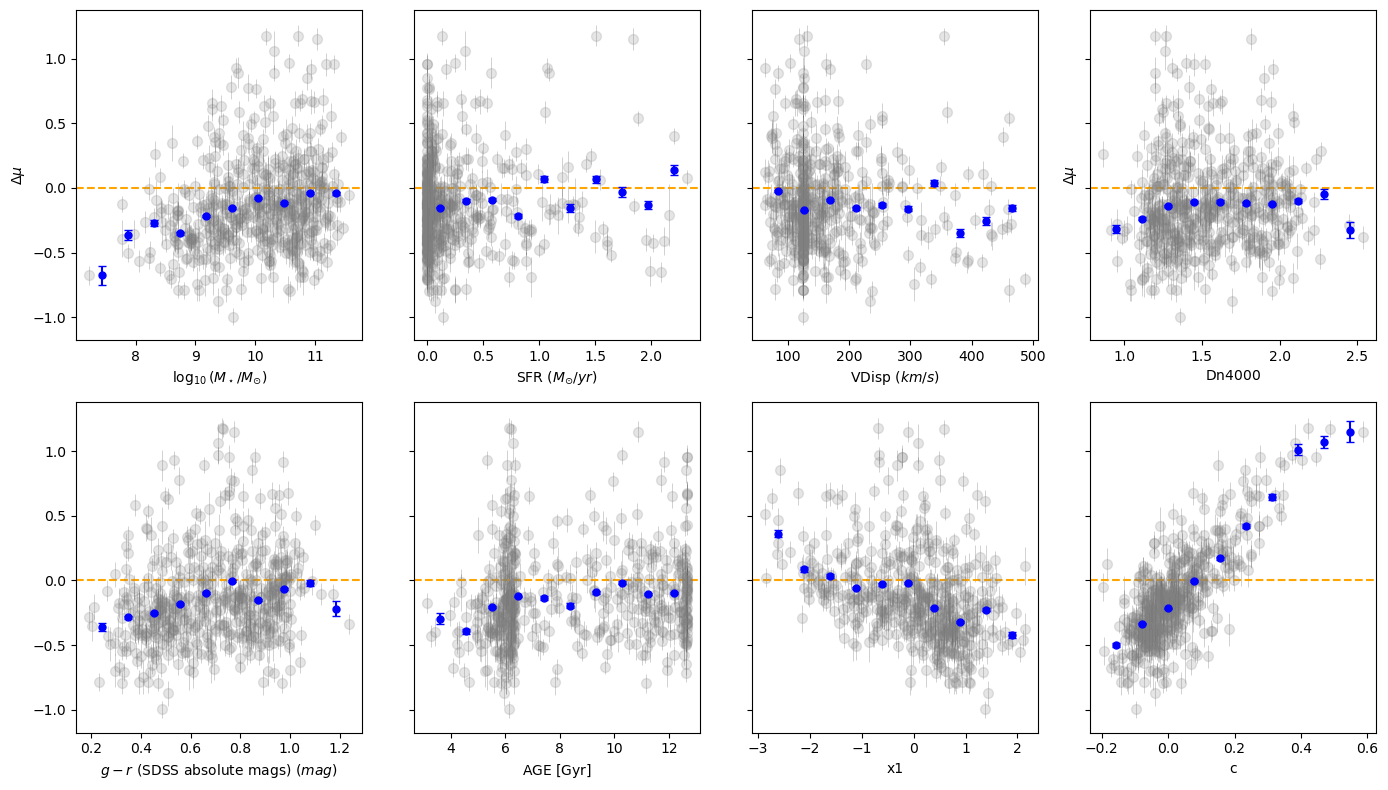

In [4]:
df = pd.read_csv("ZTF_DESI_data/ZTF_resid_cent_hostprop_no_x1_c.csv")

# -----------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df), "SNe before paper-based quality cuts.")
df = df[(df["lccoverage_flag"] == 1) & (df["fitquality_flag"] == 1)]
print(len(df), "SNe after paper-based quality cuts.")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df["SDSS_g_minus_r"] = df["ABSMAG01_SDSS_G"] - df["ABSMAG01_SDSS_R"]


# -----------------------------
# GLOBAL sigma-clip on residuals 
# -----------------------------
# note: this only needs to get done once.
# We will be deleting the entries in the data frame. 

resid_before = df["residual_centered"]

# drop all residuals that that are sigma clipped.
clip = sigma_clip(df["residual_centered"], sigma=3, maxiters=1)
mask_sigma = ~clip.mask  # True = keep
df = df.loc[mask_sigma].reset_index(drop=True)

#Plot for visual inspetion
resid_bins = np.linspace(-1, 2, 50)
plt.hist(resid_before, bins=resid_bins, label="Before sigma clip", color = "black")
plt.hist(df["residual_centered"], bins=resid_bins, label="After sigma clip", color = "gray")
plt.xlabel(r"$\Delta \mu$")
plt.ylabel("Count")
plt.legend()
plt.show()

print(len(df), "SNe after sigma clipping (Δμ)")


# ----------------------------------------------------------
# Define Which Data to Drop Before the Final Plots Are Shown
# ----------------------------------------------------------
# Note: we are not deciding to do any cuts to LOGMSTAR, VDISP, SDSS g-r, x1, or c.

mask_sfr    = (df["SFR"] <= 2.5)
mask_dn4000 = df["DN4000"] >= 0.5
mask_age    = df["AGE"] >= 2
combined_mask = ((df["SFR"] <= 2.5) & (df["DN4000"] >= 0.5) & (df["AGE"] >= 2))

# --------------------------------------
# Apply physical cuts one at a time
# and report how many SNe each cut removes
# --------------------------------------

# ---- 1) SFR cut ----
mask_sfr = df["SFR"] <= 2.5
n_after_sfr = np.sum(mask_sfr)
print(n_after_sfr, "SNe after SFR <= 2.5 cut.")
df = df.loc[mask_sfr].reset_index(drop=True)

# ---- 2) DN4000 cut ----
mask_dn4000 = df["DN4000"] >= 0.5
n_after_dn4000 = np.sum(mask_dn4000)
print(n_after_dn4000, "SNe after DN4000 >= 0.5 cut.")
df = df.loc[mask_dn4000].reset_index(drop=True)

# ---- 3) AGE cut ----
mask_age = df["AGE"] >= 2
n_after_age = np.sum(mask_age)
print(n_after_age, "SNe after AGE >= 2 Gyr cut.") 
df = df.loc[mask_age].reset_index(drop=True)

# -----------------------------
# Read the y-err collumn 
# -----------------------------
# note: must be done after all the sigma clipping
# and physical cuts have been taken care of. 
yerr_all = df["sigma_mu_meas"]



# ****************************************************************************
# ----------------------------------------------------------------------------
# Set up 2x4 grid - RESIDUALS + LIGHT CURVE PARAMETERS + ERRORS + BINS w/t ERRORS
# ----------------------------------------------------------------------------
# ****************************************************************************

# global number of bins
nbins = 10

fig, axes = plt.subplots(2, 4, figsize=(14, 8), sharey=True)
axes = axes.flatten()

point_kwargs = dict(alpha=0.2, s=50, color="grey", zorder=3)   

# --------------------------------------
# 1) LOGMSTAR
# --------------------------------------
ax = axes[0]

# # finite values mask (same as before)
# mask_logm = np.ones(len(df), dtype=bool)
# print(np.sum(mask_logm), "SNe after LOGMSTAR cut.")

# NOTE: we no longer define masks here because we now DROP any unwanted rows
# upstream (sigma-clip + physical cuts). Therefore the dataframe `df` is already
# the final cleaned sample when plotting.

# Use helper function with binning ON
scatter_with_errors(ax, "LOGMSTAR", nbins=nbins)

# Axis labels
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
ax.set_ylabel(r"$\Delta \mu$")

# --------------------------------------
# 2) SFR (cut SFR > 2.5)
# --------------------------------------
ax = axes[1]

# Exclude SFR > 2.5
# NOTE: this cut is now applied upstream by dropping rows from df,
# so we do not define a mask here anymore.

scatter_with_errors(ax, "SFR", nbins=nbins)

ax.set_xlabel(r"${\rm SFR}\ (M_{\odot}/yr)$")

# --------------------------------------
# 3) VDISP
# --------------------------------------
ax = axes[2]

# NOTE: we assume df has already been cleaned upstream, so we do not apply
# an isfinite mask here anymore.

scatter_with_errors(ax, "VDISP", nbins=nbins)

ax.set_xlabel(r"${\rm VDisp }\  (km/s) $")

# --------------------------------------
# 4) DN4000  (cut DN4000 < 0.5)
# --------------------------------------
ax = axes[3]

# keep only finite values AND DN4000 >= 0.5
# NOTE: this cut is now applied upstream by dropping rows from df,
# so we do not define a mask here anymore.

scatter_with_errors(ax, "DN4000", nbins=nbins)

ax.set_xlabel(r"${\rm Dn4000}$")
ax.set_ylabel(r"$\Delta \mu$")

# --------------------------------------
# 5) SDSS g - r
# --------------------------------------
ax = axes[4]

# NOTE: we assume df has already been cleaned upstream, so we do not apply
# an isfinite mask here anymore.

scatter_with_errors(ax, "SDSS_g_minus_r", nbins=nbins)

ax.set_xlabel(r"$g - r~{\rm (SDSS ~ absolute ~ mags)}\ (mag)$")

# --------------------------------------
# 6) AGE  (cut AGE < 2)
# --------------------------------------
ax = axes[5]

# keep only finite AGE and AGE >= 2
# NOTE: this cut is now applied upstream by dropping rows from df,
# so we do not define a mask here anymore.

scatter_with_errors(ax, "AGE", nbins=nbins)

ax.set_xlabel(r"${\rm AGE}\ [{\rm Gyr}]$")

# --------------------------------------
# 7) x1 (NEW)
# --------------------------------------
ax = axes[6]

# NOTE: we assume df has already been cleaned upstream, so we do not apply
# an isfinite mask here anymore.

scatter_with_errors(ax, "x1", nbins=nbins)

ax.set_xlabel("x1")

# --------------------------------------
# 8) c (NEW)
# --------------------------------------
ax = axes[7]

# NOTE: we assume df has already been cleaned upstream, so we do not apply
# an isfinite mask here anymore.

scatter_with_errors(ax, "c", nbins=nbins)

ax.set_xlabel("c")

# --------------------------------------
# Global cosmetics
# --------------------------------------

fig.tight_layout()
plt.show()


# Note to keep in line with Mi's Example, we are only Using x1,c, an hostmass #

Also note: the data set has already been cut for the paper quality cuts as well as the host galaxy cuts. We're just using x1,c, and hostmass at the momoent for hte purpsoe of simplicity here. 

[0.12619854 0.22430491 0.64949655]


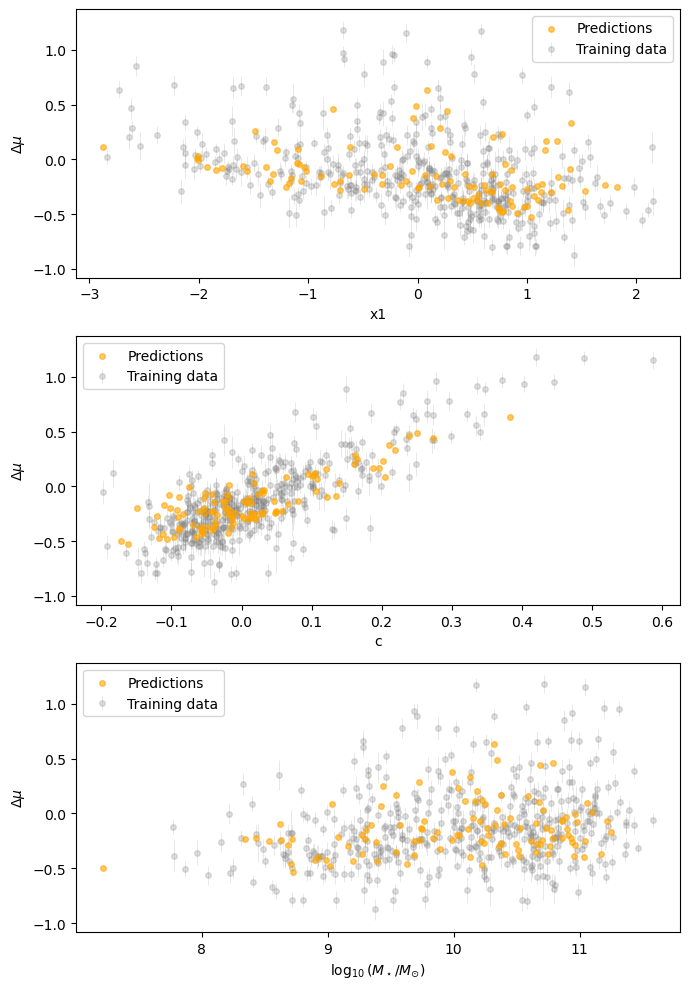

In [5]:
# =====================================================
# MI DAI ML TRAINING BLOCK 
# =====================================================

# Constructing the Random Forest Regressor Model
# Nothing is being fit here, uts just being made.

# Key properties of this model:
# - 1000 trees. 
# - Trees are allowed to grow deep (no max depth)
# - A minimum number of samples per leaf (5) enforces
#   local averaging and limits overfitting
# - At each split, only a subset of features is considered
#   (sqrt of total), encouraging diverse tree structures
# - Bootstrap resampling ensures each tree sees a slightly
#   different realization of the data

rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
)

# Defining Features and Setting Up Our Train/Test Split

feature_cols = [
    "LOGMSTAR",
    "x1",
    "c"
]

target_col = "residual_centered"

X = df[feature_cols]
y = df[target_col]


# -----------------------------------------------------
# Train / test split
# -----------------------------------------------------
# NOTE: we split X, y, *and* yerr together so that
# the measurement errors stay perfectly aligned with
# the training and testing samples.

Xtr, Xte, ytr, yte, yerr_tr, yerr_te = train_test_split(
    X, y, yerr_all, test_size=0.2, random_state=42
)

# -----------------------------------------------------
# Defining standard error as well as weights and fitting the model
# -----------------------------------------------------
# In real code each data point would have its own weight to contribute to the fit.
# NOTE: in this dataset we DO have per-point errors (sigma_mu_meas),
# so we use inverse-variance weighting here.

w = 1.0 / (yerr_tr**2)

rf.fit(Xtr, ytr, sample_weight=w)
yhat = rf.predict(Xte)

# Plots feature importance of x1, c, and hostmass in that order.
print(rf.feature_importances_)

# -----------------------------------------------------
# Plotting Results
# -----------------------------------------------------

plt.figure(figsize=(7, 10))

# --------------------------------------
# x1
# --------------------------------------
plt.subplot(3, 1, 1)

# Training data with error bars
plt.errorbar(
    Xtr["x1"], ytr,
    yerr=yerr_tr,
    fmt="o",
    markersize=4,
    alpha=0.25,
    color="gray",
    ecolor="gray",
    elinewidth=0.5,
    capsize=0,
    label="Training data",
    zorder = 1
)

# Predictions (no error bars)
plt.scatter(
    Xte["x1"], yhat,
    alpha=0.6,
    s = 16,
    color="orange",
    label="Predictions",
    zorder = 2
)

plt.xlabel("x1")
plt.ylabel(r"$\Delta \mu$")
plt.legend()

# --------------------------------------
# c
# --------------------------------------
plt.subplot(3, 1, 2)

plt.errorbar(
    Xtr["c"], ytr,
    yerr=yerr_tr,
    fmt="o",
    markersize=4,
    alpha=0.25,
    color="gray",
    ecolor="gray",
    elinewidth=0.5,
    capsize=0,
    label="Training data",
    zorder = 1
)

plt.scatter(
    Xte["c"], yhat,
    alpha=0.6,
    s = 16,
    color="orange",
    label="Predictions",
    zorder = 2
)

plt.xlabel("c")
plt.ylabel(r"$\Delta \mu$")
plt.legend()

# --------------------------------------
# hostmass (LOGMSTAR)
# --------------------------------------
plt.subplot(3, 1, 3)

plt.errorbar(
    Xtr["LOGMSTAR"], ytr,
    yerr=yerr_tr,
    fmt="o",
    markersize=4,
    alpha=0.25,
    color="gray",
    ecolor="gray",
    elinewidth=0.5,
    capsize=0,
    label="Training data",
    zorder = 1
)

plt.scatter(
    Xte["LOGMSTAR"], yhat,
    alpha=0.6,
    s = 16,
    color="orange",
    label="Predictions",
    zorder = 2
)

plt.xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
plt.ylabel(r"$\Delta \mu$")
plt.legend()

plt.tight_layout()
plt.show()

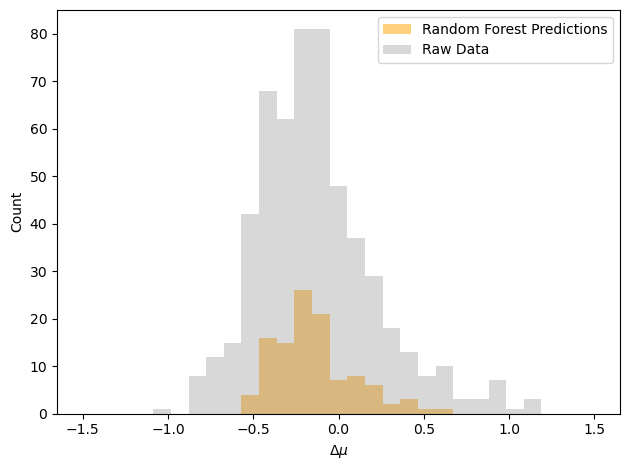

In [6]:
# --------------------------------------
# Compare distributions of raw residuals vs RF predictions
# --------------------------------------

# Use full-sample residuals (this is your cleaned df at this point)
y = df[target_col].to_numpy()

bins = np.linspace(-1.5,1.5,30)

# RF predictions (test set)
plt.hist(
    yhat,
    bins=bins,
    alpha=0.5,
    color="orange",
    label="Random Forest Predictions"
)

# Raw data (full sample)
plt.hist(
    y,
    bins=bins,
    alpha=0.3,
    color="grey",
    label="Raw Data"
)

plt.xlabel(r"$\Delta \mu$")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# Mi's Proof of Concept #

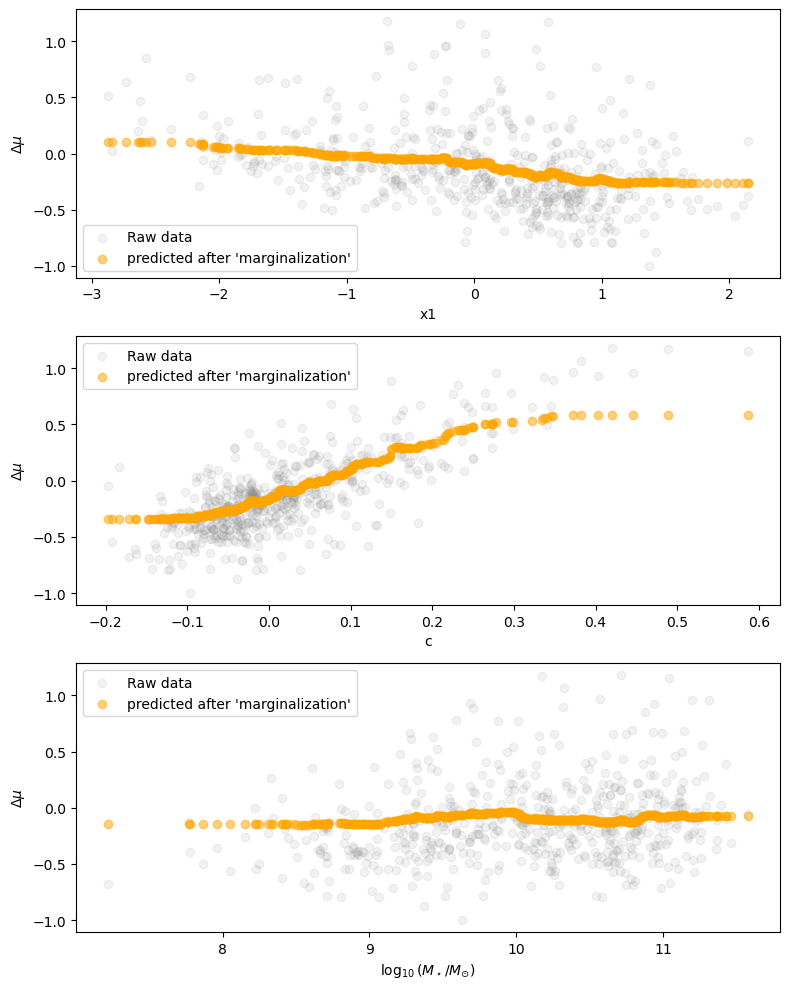

In [7]:
# =====================================================
# MEAN-FREEZING "MARGINALIZATION" PLOTS (PI SHORTCUT)
# =====================================================

# We have machine learning model where we can get x1 c and host mass and we get prediction of hubble residuals. Here there is no integration 
# being made but rather a mean value is taken. For Mykola: be sure to actually integrate as part of the marginalization process. 

# What is happening here is called "mean freezing". 

plt.figure(figsize=(8, 10))

# (Modern) Define the feature names used in your current pipeline
# NOTE: hostmass is LOGMSTAR in your df/X now
feature_list = ["x1", "c", "LOGMSTAR"]

# Loops through each of our host features.
for i, p in enumerate(feature_list):

    # frames subllots for our data. (i+1 is just an index here)
    plt.subplot(3, 1, i + 1)

    Xtest = X.copy()  # Makes a copy of the features data frame. 

    # Look at the features x1, c, and hostmas. Ingore the one were currently on (p).
    # For each of the remianing features do the following.
    # "Loop thorugh the list of host mass parameter and if they're not equal to the 
    # current parameter p, then take the mean of the other 2  parameters and fix the 
    # whole collumn to that mean value.
    for p2 in [pi for pi in feature_list if pi != p]:
        # Compute a mean of p2 parameters (replacing the whole collumn with the mean value of that column)
        Xtest[p2] = Xtest[p2].mean()

    # Predict the hubble residuals using the random forest model after mean averaging over the other 2 parameters.
    # You can use model to predict anything even your training data. 
    ytest = rf.predict(Xtest)

    # (Modern) y should be aligned with X (same rows)
    # If you defined y = df[target_col], you can use y directly; convert to numpy for safety.
    y_raw = np.asarray(y)

    plt.scatter(Xtest[p], y_raw, alpha=0.1, label="Raw data", color = "gray")
    plt.scatter(Xtest[p], ytest, alpha=0.5, label="predicted after 'marginalization'", color = "orange")

    # (Modern) nicer x-axis label for LOGMSTAR
    if p == "LOGMSTAR":
        plt.xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
    else:
        plt.xlabel(p)

    plt.ylabel(r'$\Delta\mu$')
    plt.legend()

plt.tight_layout()
plt.show()

# Performing the Actual Marginalization #

In [8]:
# IMPORTANT: columns must be in the same order as training
feature_cols = ["LOGMSTAR", "x1", "c"]

def residuals_funct(hostmass,c, x1):
    # Create a DataFrame with x1, c, and hostmass (LOGMSTAR)
    data = {
        "LOGMSTAR": [hostmass],
        "c": [c],
        "x1": [x1],
    }
    table = pd.DataFrame(data)

    # IMPORTANT: columns must be in the same order as training
    table = table[feature_cols]

    # The Random Forest algorithm defines a mapping 
    # of the host galaxy paremters to the residuals of the SNe.
    # This mapping can be treated like a function (just like 
    # we think of it as a traditional polynomial function). 
    # The [0] at the end extracts the number from the array
    # returned by predict().
    return rf.predict(table)[0]

In [9]:
def funct_x1(hostmass, c, x1):
    # Inputs are:
    # funct - to be integrated. 
    # ranges over which to integrate. 
    # ranges - limits of integration.
    # args - 
    f = scipy.integrate.nquad(
        residuals_funct,
        [[hostmass.min(), hostmass.max()], [c.min(), c.max()]],
        args=(x1,),
        opts=[{}, {}]
    )[0]
    
    print(hostmass.min(), hostmass.max(), c.min(), c.max())
    # normalize by the (c, hostmass) integration volume so this is an average
    norm = (c.max() - c.min()) * (hostmass.max() - hostmass.min())

    return f / norm

In [10]:
print(Xte)


      LOGMSTAR        x1         c
195   9.268835  0.178042 -0.125376
79   10.164773 -2.871876  0.014591
480   8.925906  0.642380 -0.056700
109  10.209505 -0.251610  0.030345
522  10.024099  0.297522 -0.020322
..         ...       ...       ...
543  10.744980  1.100941 -0.014679
140   8.708845  0.740192 -0.065525
371   8.622909  0.850731  0.121344
18    9.681180  1.822387  0.023387
323  11.057519 -1.095494  0.100328

[110 rows x 3 columns]


In [11]:
# IMPORTANT: columns must be in the same order as training
feature_cols = ["LOGMSTAR", "x1", "c"]

def residuals_funct(hostmass,c, x1):
    # Create a DataFrame with x1, c, and hostmass (LOGMSTAR)
    data = {
        "LOGMSTAR": [hostmass],
        "c": [c],
        "x1": [x1],
    }
    table = pd.DataFrame(data)

    # IMPORTANT: columns must be in the same order as training
    table = table[feature_cols]

    # The Random Forest algorithm defines a mapping 
    # of the host galaxy paremters to the residuals of the SNe.
    # This mapping can be treated like a function (just like 
    # we think of it as a traditional polynomial function). 
    # The [0] at the end extracts the number from the array
    # returned by predict().
    return rf.predict(table)[0]

$$
f(x_1)
=
\frac{1}{\left( c_{\max} - c_{\min} \right)
          \left( M_{\max} - M_{\min} \right)}
\int_{c_{\min}}^{c_{\max}}
\int_{M_{\min}}^{M_{\max}}
\mathrm{residuals\_funct}(M, c, x_1)
\, \mathrm{d}M \, \mathrm{d}c
$$


$$
f(x_1)
;\approx;
\frac{1}{(c_{\max}-c_{\min})(M_{\max}-M_{\min})}
\sum_{j=1}^{N_c}
\sum_{i=1}^{N_M}
\mathrm{residuals_funct}(M_i, c_j, x_1);
\Delta M,\Delta c
$$

$$
g(M, x_1)

\frac{1}{c_{\max}-c_{\min}}
\int_{c_{\min}}^{c_{\max}}
\mathrm{residuals_funct}(M, c, x_1), dc
$$

$$
f(x_1)

\frac{1}{M_{\max} - M_{\min}}
\int_{M_{\min}}^{M_{\max}}
\mathrm{residuals_funct}(M, x_1), dM
$$

$$
f(x_{1,k})
\approx
\frac{1}{M_{\max}-M_{\min}}
\sum_{i=1}^{N_M}\mathrm{residuals_funct}(M_i,x_{1,k}),\Delta M
$$


In [12]:
def funct_x1(hostmass, c, x1):

    # note: scipy.integrate,nquad function will integrate variables in the order
    # they are parsed into the function to be integrated.
    # Here hostmass is first, then c, then x1 (which is held constant during integration).
    # [0] extracts the integral value otherwise the output would be a touple.
    f = scipy.integrate.nquad(
        residuals_funct, # function to be integrated.
        [[hostmass.min(), hostmass.max()], [c.min(), c.max()]], # limits of integration must match order of inputs in function
        args=(x1,),  # the variable in the function we must keep constant.
    )[0]
    
    # normalize by the (c, hostmass) integration volume so this is an average
    norm = (c.max() - c.min()) * (hostmass.max() - hostmass.min())

    return f / norm


In [13]:
print(Xte)

      LOGMSTAR        x1         c
195   9.268835  0.178042 -0.125376
79   10.164773 -2.871876  0.014591
480   8.925906  0.642380 -0.056700
109  10.209505 -0.251610  0.030345
522  10.024099  0.297522 -0.020322
..         ...       ...       ...
543  10.744980  1.100941 -0.014679
140   8.708845  0.740192 -0.065525
371   8.622909  0.850731  0.121344
18    9.681180  1.822387  0.023387
323  11.057519 -1.095494  0.100328

[110 rows x 3 columns]


In [14]:
x1_grid = np.linspace(-3, 3, 3)

y_values = []
for i in x1_grid:
    y = funct_x1(
        hostmass=Xte["LOGMSTAR"],
        c=Xte["c"],
        x1=i
    )
    y_values.append(y)
y_grid = np.array(y_values)

plt.scatter(x1_grid, y_grid, alpha=0.6, s=50, color="blue", label="Marginalized prediction")

plt.errorbar(
    Xtr["x1"], ytr,
    yerr=yerr_tr,
    fmt="o",
    markersize=4,
    alpha=0.25,
    color="gray",
    ecolor="gray",
    elinewidth=0.5,
    capsize=0,
    label="Training data",
    zorder = 1
)

plt.show()

/Users/pittsburghgraduatestudent/miniforge3/envs/ds2/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
/Users/pittsburghgraduatestudent/miniforge3/envs/ds2/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 


KeyboardInterrupt: 

# Code that Incorrectly Integrates #

In [ ]:
# import scipy.integrate

# # IMPORTANT: columns must be in the same order as training
# feature_cols = ["LOGMSTAR", "x1", "c"]

# def residuals_funct(hostmass, x1, c):
#     # Create a DataFrame with x1, c, and hostmass (LOGMSTAR)
#     data = {
#         "LOGMSTAR": [hostmass],
#         "x1": [x1],
#         "c": [c],
#     }
#     table = pd.DataFrame(data)

#     # IMPORTANT: columns must be in the same order as training
#     table = table[feature_cols]

#     # The Random Forest algorithm defines a mapping 
#     # of the host galaxy paremters to the residuals of the SNe.
#     # This mapping can be treated like a function (just like 
#     # we think of it as a traditional polynomial function). 
#     # The [0] at the end extracts the number from the array
#     # returned by predict().
#     return rf.predict(table)[0]
    
# def funct_x1(x1, c, hostmass):
#     # Inputs are:
#     # funct - to be integrated. 
#     # ranges over which to integrate. 
#     # ranges - limits of integration.
#     # args - 
#     f = scipy.integrate.nquad(
#         residuals_funct,
#         [[c.min(), c.max()], [hostmass.min(), hostmass.max()]],
#         args=(x1,),
#         opts=[{}, {}]
#     )[0]
    
#     print(c.min(), c.max(), hostmass.min(), hostmass.max())
#     # normalize by the (c, hostmass) integration volume so this is an average
#     norm = (c.max() - c.min()) * (hostmass.max() - hostmass.min())

#     return f / norm

# print(Xte)

# x1_grid = np.linspace(-3, 3, 10)
# y_grid = np.array([funct_x1(x1v, Xte["c"], Xte["LOGMSTAR"]) for x1v in x1_grid])

# plt.scatter(x1_grid, y_grid, alpha=0.6, s=50, color="blue", label="Marginalized prediction")

# plt.errorbar(
#     Xtr["x1"], ytr,
#     yerr=yerr_tr,
#     fmt="o",
#     markersize=4,
#     alpha=0.25,
#     color="gray",
#     ecolor="gray",
#     elinewidth=0.5,
#     capsize=0,
#     label="Training data",
#     zorder = 1
# )

# plt.show()

: 

: 